# Lab 10: Infection trees and heterogeneity

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?

# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

The very first task is to import the required packages, in this lab we will analyze infection trees. To do that we will use `numpy`, `matplotlib.pyplot`, `polars`, and `networkx`

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):


In [1]:
# TODO: Import the required libraries
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import networkx as nx

In [2]:
def hierarchy_pos(G, root=None, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5):

    '''
    From Joel's answer at https://stackoverflow.com/a/29597209/2966723.  
    Licensed under Creative Commons Attribution-Share Alike 
    
    If the graph is a tree this will return the positions to plot this in a 
    hierarchical layout.
    
    G: the graph (must be a tree)
    
    root: the root node of current branch 
    - if the tree is directed and this is not given, 
      the root will be found and used
    - if the tree is directed and this is given, then 
      the positions will be just for the descendants of this node.
    - if the tree is undirected and not given, 
      then a random choice will be used.
    
    width: horizontal space allocated for this branch - avoids overlap with other branches
    
    vert_gap: gap between levels of hierarchy
    
    vert_loc: vertical location of root
    
    xcenter: horizontal location of root
    '''
    if not nx.is_tree(G):
        raise TypeError('cannot use hierarchy_pos on a graph that is not a tree')

    if root is None:
        if isinstance(G, nx.DiGraph):
            root = next(iter(nx.topological_sort(G)))  #allows back compatibility with nx version 1.11
        else:
            root = random.choice(list(G.nodes))

    def _hierarchy_pos(G, root, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5, pos = None, parent = None):
        '''
        see hierarchy_pos docstring for most arguments

        pos: a dict saying where all nodes go if they have been assigned
        parent: parent of this branch. - only affects it if non-directed

        '''
    
        if pos is None:
            pos = {root:(xcenter,vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.neighbors(root))
        if not isinstance(G, nx.DiGraph) and parent is not None:
            children.remove(parent)  
        if len(children)!=0:
            dx = width/len(children) 
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G,child, width = dx, vert_gap = vert_gap, 
                                    vert_loc = vert_loc-vert_gap, xcenter=nextx,
                                    pos=pos, parent = root)
        return pos

            
    return _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter)

# 1. Importing data
For this lab we will work with this huge dataset of transmission trees by Taube et al ([LINK](https://doi.org/10.1371/journal.pbio.3001685)). Below is some text from the paper's abstract explaining the dataset.

"We compiled a database, called OutbreakTrees, of 382 published, standardized transmission trees consisting of 16 directly transmitted diseases ranging in size from 2 to 286 cases. For each tree and disease, we calculated several key statistics, such as tree size, average number of secondary infections, the dispersion parameter, and the proportion of cases considered superspreaders, and examined how these statistics varied over the course of each outbreak and under different assumptions about the completeness of outbreak investigations."

We will utilize a few of these trees to first calculate some metrics about the outbreak in question and then finally simulate a SIR model using those metrics.

The very first step is to load the data, we have two files for our data, one for the edges and one for the nodes. Each file has a column called ID used to identify the network our node/edge is a part of.

For this step we have provided the code to load the data into a dictionary called `trees`. Your job is to try and understand how we do this and comment the code.


In [3]:
df_edges = pl.read_csv("edgelists.csv") # filepath for edges, from Canvas
df_nodes = pl.read_csv("node_info.csv") # filepath for edges, from Canvas

## Create list of unique nodes
tree_names = df_nodes["id"].unique().to_list()

## Create a dictionary of trees
trees = {}

## For each tree, create graph and add nodes and edges from the edges/nodes dfs
for t in tree_names:
    G = nx.DiGraph()
    G.add_nodes_from(df_nodes.filter(df_nodes["id"] == t)["name"].to_list())
    edges = df_edges.filter(df_edges["id"] == t)
    G.add_edges_from(zip(edges["from"].to_list(), edges["to"].to_list()))
    G.name = t
    trees[t] = G
print(trees)

{'chn.2020.covid.5.00': <networkx.classes.digraph.DiGraph object at 0x00000277EF5D97F0>, 'chn.2020.covid.11.10': <networkx.classes.digraph.DiGraph object at 0x00000277EF5FC410>, 'chn.2020.covid.15.01': <networkx.classes.digraph.DiGraph object at 0x00000277EF5FC2D0>, 'hkg.2020.covid.1.68': <networkx.classes.digraph.DiGraph object at 0x00000277EF5E15B0>, 'kor.2020.covid.5.03': <networkx.classes.digraph.DiGraph object at 0x00000277EF5E1220>, 'hkg.2020.covid.1.67': <networkx.classes.digraph.DiGraph object at 0x00000277EF5F15B0>, 'ita.2020.covid.1.00': <networkx.classes.digraph.DiGraph object at 0x00000277EF5AB680>, 'ita.1982.hepa.1.05': <networkx.classes.digraph.DiGraph object at 0x00000277EF5A8490>, 'chn.2020.covid.18.00': <networkx.classes.digraph.DiGraph object at 0x00000277EF4E7C50>, 'rou.2020.covid.1.10': <networkx.classes.digraph.DiGraph object at 0x00000277EF5D2150>, 'aut.2020.covid.1.00': <networkx.classes.digraph.DiGraph object at 0x00000277EF519D60>, 'hkg.2019.meas.1.00': <networ

# 2. Choosing our trees

For this analysis we will only look at two trees, so we can choose the two largest trees to analyze. We will use `np.argsort` to sort our trees based on how many edges each of them has and then take the two largest trees from the output list of indices.

Note: `np.argsort` sorts in ascending order by default, so we choose the two trees from the end of the resulting list. Also it gives us a list of indices of trees and not the trees itself. Use these indices to extract the tree name and then use that name to extract the network itself from the dictionary of trees.

**Extra Credit**: Use subplots to plot two side-by-side networks for 0.5 EC.

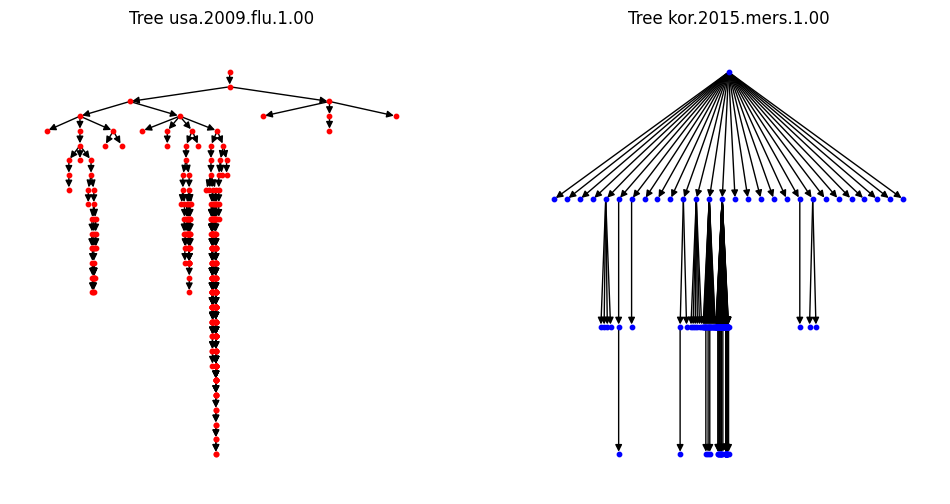

In [7]:
# TODO: Fill the blanks with correct variables
sorted_tree_id = np.argsort([trees[t].number_of_edges() for t in tree_names])

# sorted_tree_id gives indices into tree_names, so extract actual IDs
largest_two_ids = [tree_names[i] for i in sorted_tree_id[-2:]]
 
# TODO: Choose the two largest trees, tree_1 and tree_2 are graphs
tree_1 = trees[largest_two_ids[-1]]   # largest
tree_2 = trees[largest_two_ids[-2]]   # second-largest



# TODO: Draw the trees as well! (use both nx.draw)
# nx.draw(tree_1, node_size=10, node_color="red", pos=hierarchy_pos(tree_1))  # Draw tree_1
# Do the same for tree_2; Extra credit if you alter the code to plot as plt.subplots


# nx.draw(tree_2, node_size=10, node_color="blue", pos=hierarchy_pos(tree_2))


### plotting both trees side by side using plt.subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].set_title(f"Tree {largest_two_ids[-1]}")
nx.draw(tree_1, node_size=10, node_color="red",
        pos=hierarchy_pos(tree_1), ax=axs[0])

axs[1].set_title(f"Tree {largest_two_ids[-2]}")
nx.draw(tree_2, node_size=10, node_color="blue",
        pos=hierarchy_pos(tree_2), ax=axs[1])

plt.show()


# 3. Finding $R_0$ and quantifying heterogeneity
### 3.1 $R_0$
The most basic and popular metric people use to define epidemics is $R_0$. It is the basic reproduction number for an epidemic and its value can describes the initial contagiousness of an infectious disease. It represents the average number of new infections caused by one infected person in a completely susceptible population, in the absence of any public health interventions or prior immunity. 

$R_0$ tells us if the epidemic will spread, stabilize or die off:
*   If $R_0 < 1$, the disease will eventually decline and die out because each existing infection causes, on average, less than one new infection.
*   If $R_0 = 1$, the disease will remain stable within the population, with each case leading to approximately one new case.
*   If $R_0 > 1$, the disease has the potential to spread and cause an outbreak or epidemic.

We can calculate the $R_0$ of an infection tree as the average number of infections caused by each individual (node). So for a `nx.DiGraph()` it becomes the average out degree for the network.

Calculate and print $R_0$ for our two graphs.

Note: `[G.out_degree(n) for n in G.nodes]` gives us a list of out-degrees for each node. Use this to find the average out degree of our two networks, here G is replaced with the name of your graph. 

In [8]:
# TODO: Find the average out degree

## loop through all nodes and get out degree values for tree_1, then take mean of list
out_deg_1_vals = [tree_1.out_degree(n) for n in tree_1.nodes()]
R0_1 = np.mean(out_deg_1_vals)

# TODO: Do the same thing for tree_2
out_deg_2_vals = [tree_2.out_degree(n) for n in tree_2.nodes()]
R0_2 = np.mean(out_deg_2_vals)


print("R0 for tree_1:", R0_1)
print("R0 for tree_2:", R0_2)


R0 for tree_1: 0.9965034965034965
R0 for tree_2: 0.9946236559139785


What were the $R_0$ values for our trees? What does that mean?

The values are above. Both are slightly below one; each infected person, on average, infects one additional person. 



### 3.2 Heterogeneity

Is $R_0$ a complete measure? Turns out it is not! Heterogeneity, or individual variation in susceptibility, infectiousness, and contact patterns, plays a crucial role in disease transmission dynamics and significantly affects the interpretation and estimation of $R_0$. Traditional simple $R_0$ models often assume a well-mixed, homogeneous population, which is rarely the case in reality.

To better understand and predict epidemic dynamics, epidemiologists look beyond a single $R_0$ value and consider the full distribution of secondary infections. Which in our case becomes the out-degree distribution!

Lets plot bar graphs for our out-degrees!

**Extra Credit**: Use subplots to plot two side-by-side plots for 0.5 EC.

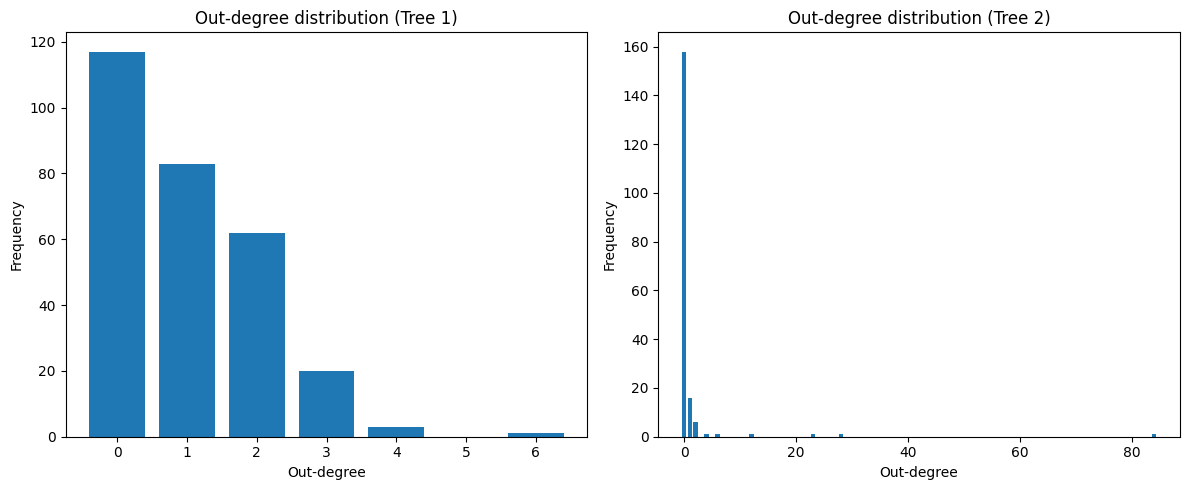

In [11]:
# TODO: Plotting for tree 1

## create a sorted list of out-degrees, then get unique degrees and their frequencies
## plot unique degrees vs frequencies as bar plot
degrees_ls_1 = sorted([d for n, d in tree_1.out_degree()])
deg_1, freq_1 = np.unique(degrees_ls_1, return_counts=True)
# plt.bar(deg_1, freq_1)
# plt.title("Out-degree distribution (Tree 1)")
# plt.xlabel("Out-degree (secondary infections)")
# plt.ylabel("Frequency")
# plt.show()

# TODO: Do the same for tree 2
degrees_ls_2 = sorted([d for n, d in tree_2.out_degree()])
deg_2, freq_2 = np.unique(degrees_ls_2, return_counts=True)
# plt.bar(deg_2, freq_2)
# plt.title("Out-degree distribution (Tree 2)")
# plt.xlabel("Out-degree (secondary infections)")
# plt.ylabel("Frequency")
# plt.show()


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Tree 1
degrees_ls_1 = sorted([d for n, d in tree_1.out_degree()])
deg_1, freq_1 = np.unique(degrees_ls_1, return_counts=True)
axs[0].bar(deg_1, freq_1)
axs[0].set_title("Out-degree distribution (Tree 1)")
axs[0].set_xlabel("Out-degree")
axs[0].set_ylabel("Frequency")

# Tree 2
degrees_ls_2 = sorted([d for n, d in tree_2.out_degree()])
deg_2, freq_2 = np.unique(degrees_ls_2, return_counts=True)
axs[1].bar(deg_2, freq_2)
axs[1].set_title("Out-degree distribution (Tree 2)")
axs[1].set_xlabel("Out-degree")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Do you notice anything from these plots? What can you say about the epidemic from these plots?


Tree one has a more spread-out out-degree distribution. Tree 2 is more concentrated in a few nodes. 

### 3.2 Quantifying heterogeneity

These plots show us something important, they tell us that there is heterogeneity in our spreaders. But they dont tell us how much heterogeneity there is, remember that $R_0$ told us on average how many secondary infections each infected individual causes. So, any large deviation from that would either mean you dont cause a lot of infections OR you cause a lot of infections, making you a super spreader!

So, to quantify this heterogeneity and see if the epidemic is spreading uniformly or due to super-spreaders, we can find the variance (or standard deviation) of the degree distribution. Remember the mean of our degree distribution was $R_0$ so its variance tells us how much our individuals deviate from that mean.

NOTE: You can use `np.std` to find the standard deviation and then normalize it using the mean of our distribution. This gives us the coefficient of variation, CV > 1 means high variance and CV < 1 means low variance.

In [12]:
# TODO: Use np.std and np.mean to find the CV of tree 1 and tree 2

## Calculate CV for tree_1 and tree_2 by using the SD for the out values / the mean
CV_1 = np.std(out_deg_1_vals) / np.mean(out_deg_1_vals)
CV_2 = np.std(out_deg_2_vals) / np.mean(out_deg_2_vals)

# TODO: Print these values
print("Coefficient of Variation (Tree 1):", CV_1)
print("Coefficient of Variation (Tree 2):", CV_2)


Coefficient of Variation (Tree 1): 1.0464438012223358
Coefficient of Variation (Tree 2): 6.764978781258952


Explain what these values tell us about the networks of our choice? How can $R_0$ be misleading if our CV is high?

# 4. Lets make our own infection trees!

In this section we will use the stochastic model from Lab 9 (with some modifications) to create our own infection trees!

This is still a simple SI model, but whenever a node gets infected we add an edge between the nodes in an empty `nx.DiGraph()`.

Since there are some modifications, this section will be a FITB.

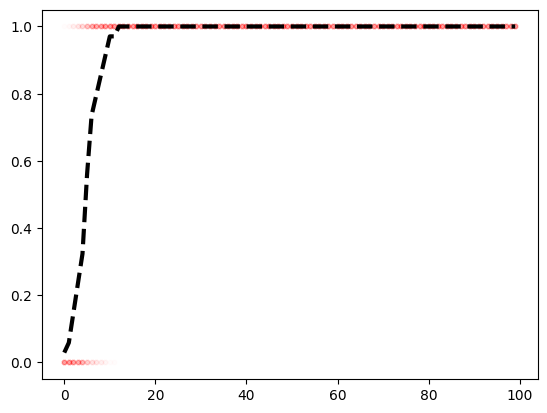

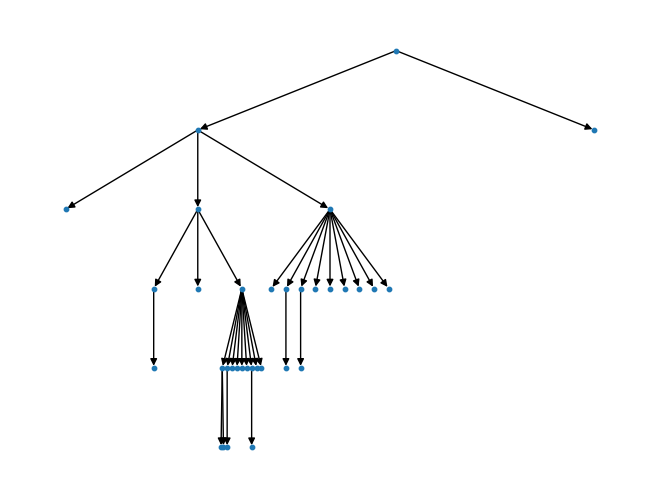

In [13]:
T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)

G_tree = nx.DiGraph()
# TODO: Define the necessary parameters
G_tree = nx.DiGraph()
beta = 0.2                              # infection probability
N = G.number_of_nodes()                 # number of nodes



# TODO: Initialize your S0 and I0
S0 = np.ones(N)                         # all susceptible initially
I0 = np.zeros(N)                        # none infected initially
I0[np.random.randint(N)] = 1            # pick a random initial infected node
S0 = 1 - I0                             # update S0 accordingly


# TODO: Create lists to store them
S = [S0]
I = [I0]



for t in range(T - 1):
    # TODO: Define I_new
    I_new = I[t].copy()

    # TODO: Note that we dont have prob_array now, but the code still works. What did we do?
    for i in range(G.number_of_nodes()):
        if I[t][i] == 0:
            for j in G.neighbors(i):
                if I[t][j] == 1:
                    if np.random.rand() < beta:
                        I_new[i] = 1
                        G_tree.add_edge(j, i)
                        break
        else:
            I_new[i] = 1

    # TODO: Append the new arrays to S and I
    S_new = 1 - I_new
    S.append(S_new)
    I.append(I_new)


# This is just plotting
for i in range(T):
    plt.scatter(i * np.ones(I[i].shape), I[i], color="red", s=10, alpha=0.01)

plt.plot(range(T), [j.mean() for j in I], "k--", linewidth=3)
plt.show()
nx.draw(G_tree, node_size=10, pos = hierarchy_pos(G_tree))

# Extra credit - 2 points
Mathematically, $R_0 = \dfrac{\beta}{\gamma} S_0$, so essentially the number of susceptibles that get infected divided by how many infected get recovered. Using the intial value of our susceptible population we can estimate different combinations of $\beta$ and $\gamma$ to match our infection tree's $R_0$.

For this excercise, we will use the well-mixed SIR model to simulate how our infection tree epidemic would have spread in a homogenous population. Does it even end up spreading or do we see the epidemic die out sooner than expected? Assume we have $\beta = 0.05$, calculate the corresponding $\gamma$ using your trees $R_0$ and population $S_0$ values. Create a well mixed SIR model with these parameters and plot the frequency changes in S, I and R compartments.

NOTE: You will have to write the equations for each compartment before you move formward with the code. Please refer to previous lab on how to form the equations, look into the extra credit with the SIS model, the only difference here will be that your infected will go into a new compartment called the `recovered` compartement (R) instead of back into S as they recover from the disease.

0.9965034965034965
0.9946236559139785
gamma1 = 0.048699690402476785
gamma2 = 0.04879173290937997


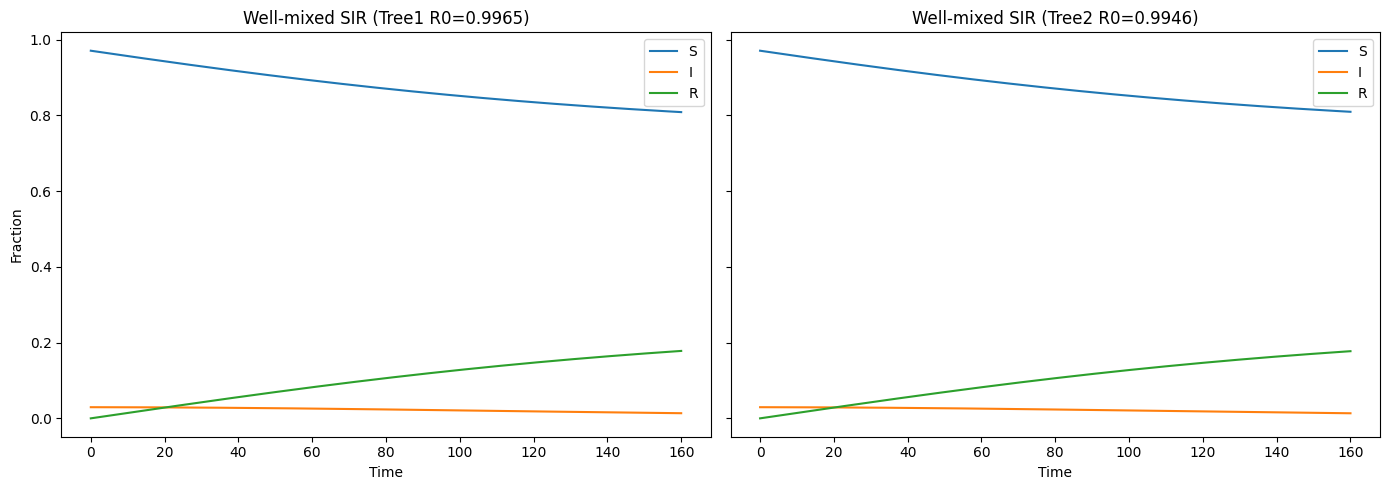

=== Summary (Tree 1 params) ===
Peak I fraction: 0.029411764705882353
Time of peak (approx): 0.0
Final susceptible fraction S(inf): 0.8084767656172162

=== Summary (Tree 2 params) ===
Peak I fraction: 0.029411764705882353
Time of peak (approx): 0.0
Final susceptible fraction S(inf): 0.8093327390390191


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
beta = 0.05
print(R0_1)
print(R0_2)


N = 34
S0 = (N - 1) / N         # initial susceptible fraction (one initial infected)

# compute gamma from R0 = (beta/gamma) * S0  => gamma = beta * S0 / R0
gamma1 = beta * S0 / R0_1
gamma2 = beta * S0 / R0_2

print("gamma1 =", gamma1)
print("gamma2 =", gamma2)

# simulation settings
T = 160          # days (or time units)
dt = 0.1
steps = int(T / dt)
t_grid = np.linspace(0, T, steps+1)

def simulate_sir(beta, gamma, S0, I0=1.0/N, R0_init=0.0):
    S = np.zeros(steps+1)
    I = np.zeros(steps+1)
    R = np.zeros(steps+1)
    S[0] = S0
    I[0] = I0
    R[0] = R0_init
    for k in range(steps):
        s = S[k]
        i = I[k]
        r = R[k]
        dS = -beta * s * i
        dI = beta * s * i - gamma * i
        dR = gamma * i
        S[k+1] = s + dS * dt
        I[k+1] = i + dI * dt
        R[k+1] = r + dR * dt
        # numerical safety: keep values in [0,1]
        S[k+1] = max(0.0, min(1.0, S[k+1]))
        I[k+1] = max(0.0, min(1.0, I[k+1]))
        R[k+1] = max(0.0, min(1.0, R[k+1]))
    return S, I, R

# run both scenarios
S1, I1, Rr1 = simulate_sir(beta, gamma1, S0)
S2, I2, Rr2 = simulate_sir(beta, gamma2, S0)

# plot
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axs[0].plot(t_grid, S1, label="S")
axs[0].plot(t_grid, I1, label="I")
axs[0].plot(t_grid, Rr1, label="R")
axs[0].set_title(f"Well-mixed SIR (Tree1 R0={R0_1:.4f})")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Fraction")
axs[0].legend()

axs[1].plot(t_grid, S2, label="S")
axs[1].plot(t_grid, I2, label="I")
axs[1].plot(t_grid, Rr2, label="R")
axs[1].set_title(f"Well-mixed SIR (Tree2 R0={R0_2:.4f})")
axs[1].set_xlabel("Time")
axs[1].legend()

plt.tight_layout()
plt.show()

# summaries
print("=== Summary (Tree 1 params) ===")
print("Peak I fraction:", I1.max())
print("Time of peak (approx):", t_grid[I1.argmax()])
print("Final susceptible fraction S(inf):", S1[-1])

print("\n=== Summary (Tree 2 params) ===")
print("Peak I fraction:", I2.max())
print("Time of peak (approx):", t_grid[I2.argmax()])
print("Final susceptible fraction S(inf):", S2[-1])
